In [93]:
import os
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms
from torchvision import models

import cv2
import matplotlib.pyplot as plt

In [94]:
os.listdir('data/dataset')

['0', '1']

In [95]:
root = 'data/dataset'

In [96]:
data_dict = {'X':[], 'y':[]}

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)
    for img in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img)
        data_dict['X'].append(img_path)
        data_dict['y'].append(int(cls))

In [97]:
pd.DataFrame(data_dict)

,X,y
0,data/dataset\0\cat1.jpg,0
1,data/dataset\0\cat2.jpg,0
2,data/dataset\0\cat3.jpg,0
3,data/dataset\0\cat4.jpg,0
4,data/dataset\0\cat5.jpg,0
5,data/dataset\1\dog1.jpg,1
6,data/dataset\1\dog2.jpg,1
7,data/dataset\1\dog3.jpg,1
8,data/dataset\1\dog4.jpg,1
9,data/dataset\1\dog5.jpg,1


In [99]:
class CustomDataset(Dataset):
    def __init__(self, data_dict: dict, transforms=None):
        self.data_dict = data_dict
        self.transforms = transforms

    def __getitem__(self, idx):
        x = cv2.imread(self.data_dict['X'][idx])
        y = self.data_dict['y'][idx]
        if self.transforms:
            x = self.transforms(x)
            y = torch.tensor(y)
        return x, y

    def __len__(self):
        return len(self.data_dict['X'])

In [100]:
trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size=(300, 300)),
    transforms.Normalize(mean=[0, 0, 0], std=[1, 1, 1])
])

cd = CustomDataset(data_dict, trans)

In [101]:
for i in cd:
    print(i[0].shape)

torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])


In [148]:
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

In [155]:
x = cd[4][0].unsqueeze(dim=0)

In [156]:
y_pred = model(x)

In [157]:
torch.argmax(y_pred)

tensor(146)

In [158]:
classes = models.ResNet50_Weights.DEFAULT.meta

In [159]:
classes.keys()

dict_keys(['min_size', 'categories', 'num_params', 'recipe', '_metrics', '_ops', '_file_size', '_docs'])

In [160]:
classes['categories'][146]

'albatross'

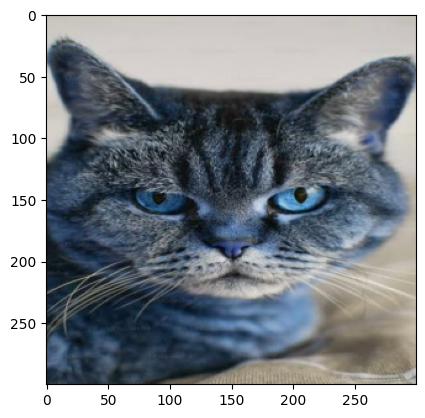

In [161]:
plt.imshow(cd[4][0].permute(1,2,0))

In [167]:
torch.argmax(F.softmax(y_pred))

C:\Users\Brian\AppData\Local\Temp\ipykernel_12964\153894831.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  torch.argmax(F.softmax(y_pred))


tensor(146)

In [170]:
F.softmax(y_pred)[0]

C:\Users\Brian\AppData\Local\Temp\ipykernel_12964\3111965656.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  F.softmax(y_pred)[0]


tensor([0.0011, 0.0009, 0.0012, 0.0010, 0.0008, 0.0009, 0.0009, 0.0012, 0.0009,
        0.0010, 0.0009, 0.0009, 0.0010, 0.0011, 0.0010, 0.0009, 0.0010, 0.0010,
        0.0010, 0.0008, 0.0009, 0.0013, 0.0013, 0.0014, 0.0010, 0.0009, 0.0009,
        0.0009, 0.0009, 0.0010, 0.0009, 0.0010, 0.0010, 0.0009, 0.0011, 0.0009,
        0.0008, 0.0010, 0.0009, 0.0011, 0.0010, 0.0010, 0.0009, 0.0011, 0.0009,
        0.0009, 0.0011, 0.0011, 0.0010, 0.0008, 0.0008, 0.0011, 0.0011, 0.0011,
        0.0008, 0.0011, 0.0009, 0.0010, 0.0009, 0.0012, 0.0012, 0.0011, 0.0010,
        0.0011, 0.0013, 0.0008, 0.0010, 0.0009, 0.0009, 0.0010, 0.0011, 0.0009,
        0.0009, 0.0012, 0.0010, 0.0011, 0.0011, 0.0012, 0.0014, 0.0012, 0.0012,
        0.0010, 0.0010, 0.0011, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0009, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0009, 0.0010, 0.0010, 0.0012, 0.0010, 0.0010, 0.0010, 0.0009,
        0.0011, 0.0010, 0.0008, 0.0010, 